# Modeling the best parameters for binding capacity

### Data importing

In [18]:
from pandas import read_csv

experiments = read_csv('../data/binding_capacity.csv', index_col="No")
experiments

,Cond [mS/cm],pH,Binding capacity
No,,,
1,5.0,4.5,96
2,15.0,4.5,102
3,5.0,5.5,137
4,15.0,5.5,4
5,5.0,5.0,139
6,15.0,5.0,54
7,10.0,4.5,119
8,10.0,5.5,84
9,10.0,5.0,121


## Creating models

$y_1 = f(x_{1}, x_{2}) = \beta_{0} + \beta_{1} x_{1} + \beta_{2} x_{2} + e$

$y_2 = f(x_{1}, x_{2}) = \beta_{0} + \beta_{1} x_{1} + \beta_{2} x_{2} + \beta_{12} x_{1} x_{2} + e$

$y_3 = f(x_{1}, x_{2}) = \beta_{0} + \beta_{1} x_{1} +  \beta_{2} x_{2} + \beta_{12} x_{1} x_{2} + \beta_{11} x_{1}^{2} + \beta_{22} x_{2}^{2} + e$





In [19]:
from doemodels.build import Model

df = experiments.copy()
df.columns= ["Cond", "pH", "Capacity"]

model1 = Model(formula="Capacity ~ Cond + pH", data=df)
model2 = Model(formula="Capacity ~ Cond * pH", data=df)
model3 = Model(formula="Capacity ~ Cond * pH + I(pH**2) + I(Cond**2)", data=df)

## Assumptions check

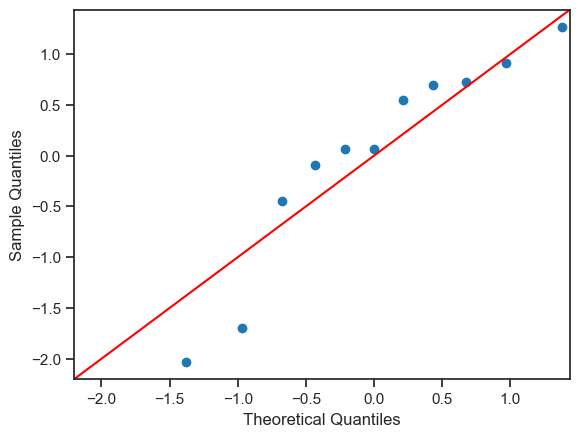

Capacity ~ Cond + pH 

           Shapiro-Wilk D'Agostino-Pearson Anderson-Darling
Statistic     0.889144           2.699501         0.539862
pvalue        0.135683           0.259305              NaN
Normal             Yes                Yes              Yes


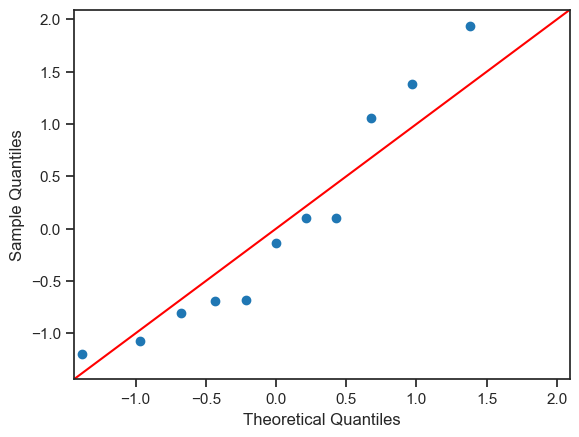

Capacity ~ Cond * pH 

           Shapiro-Wilk D'Agostino-Pearson Anderson-Darling
Statistic     0.907166           1.474396         0.443245
pvalue        0.225666           0.478453              NaN
Normal             Yes                Yes              Yes


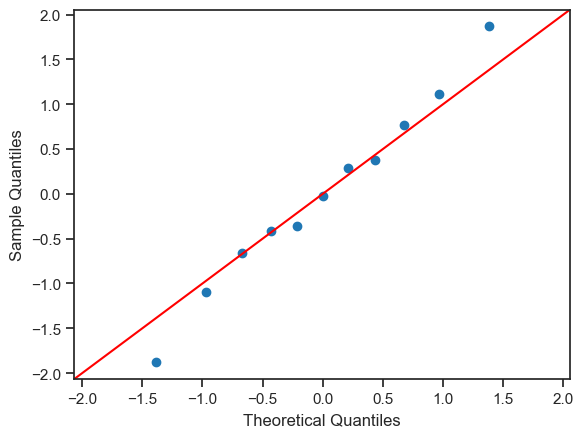

Capacity ~ Cond * pH + I(pH**2) + I(Cond**2) 

           Shapiro-Wilk D'Agostino-Pearson Anderson-Darling
Statistic     0.995991           0.089131         0.105657
pvalue        0.999962           0.956413              NaN
Normal             Yes                Yes              Yes


In [20]:
print(model1.formula, "\n"*2, model1.normality())
print(model2.formula, "\n"*2, model2.normality())
print(model3.formula, "\n"*2, model3.normality())

For all three models the residual are normally distributed.

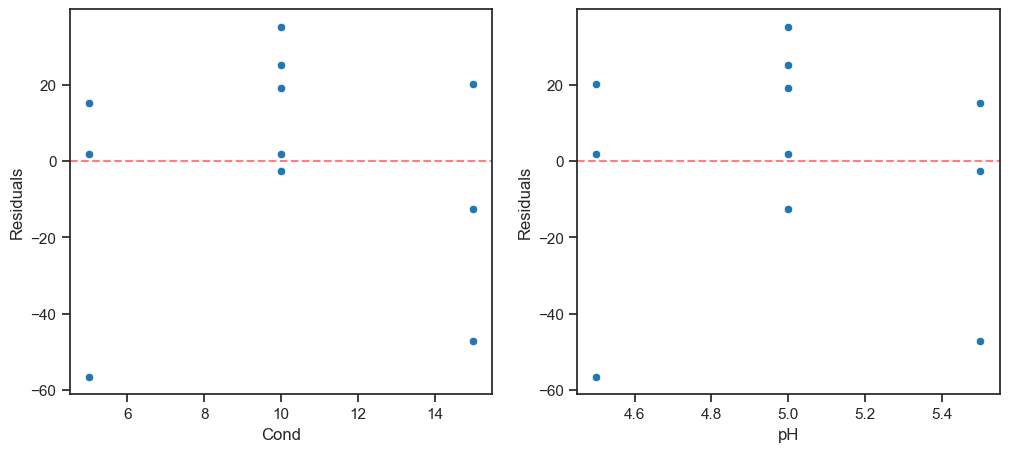

Capacity ~ Cond + pH 

               Breusch-Pagan
Statistic          0.286815
pvalue             0.866401
Homoscedastic           Yes


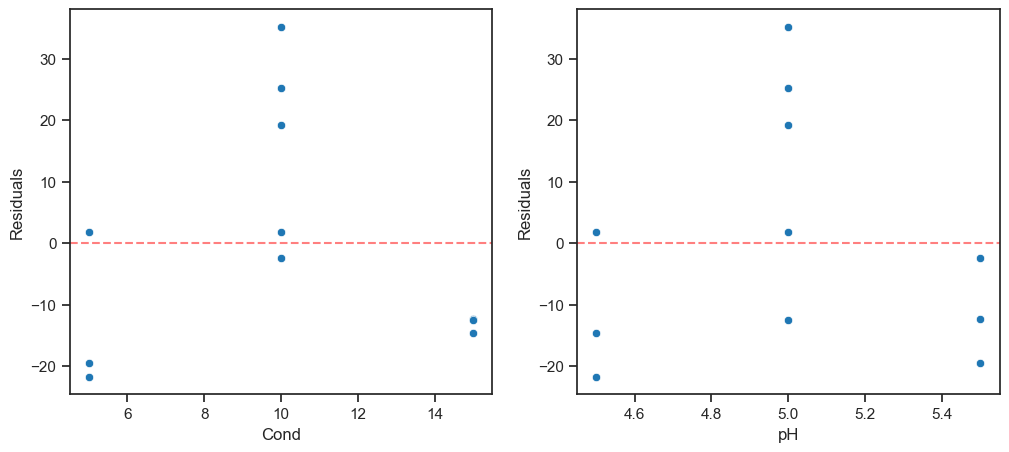

Capacity ~ Cond * pH 

               Breusch-Pagan
Statistic          0.186811
pvalue              0.97969
Homoscedastic           Yes


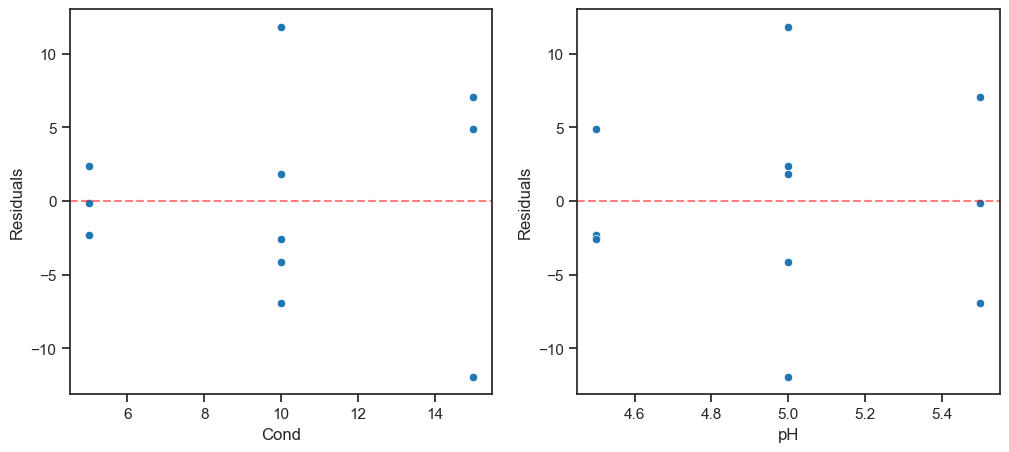

Capacity ~ Cond * pH + I(pH**2) + I(Cond**2) 

               Breusch-Pagan
Statistic           4.82108
pvalue             0.438104
Homoscedastic           Yes


In [21]:
print(model1.formula, "\n"*2, model1.homoscedasticity(groups=["Cond", "pH"]))
print(model2.formula, "\n"*2, model2.homoscedasticity(groups=["Cond", "pH"]))
print(model3.formula, "\n"*2, model3.homoscedasticity(groups=["Cond", "pH"]))

Breusch-Pagan confirmed that residuals are homoscedastic.

## Analysis of variance (ANOVA) and metrics

In [22]:
model1.metrics_table

,Capacity ~ Cond + pH
R squared (adjusted),0.390877
R squared,0.512701
BIC,111.508029
AIC,110.314343
RMSE,27.732985


In [23]:
model2.metrics_table

,Capacity ~ Cond * pH
R squared (adjusted),0.701308
R squared,0.790915
BIC,104.598409
AIC,103.006828
RMSE,18.166035


In [24]:
model3.metrics_table

,Capacity ~ Cond * pH + I(pH**2) + I(Cond**2)
R squared (adjusted),0.949023
R squared,0.974512
BIC,86.244562
AIC,83.857190
RMSE,6.342655


Second-order polynomial model has the best statistics. Model explains the most of the data variance. It has the lowest BIC/AIC and RMSE values.

In [25]:
model3.anova_table

,DF,Sum of Squares,Mean square,F,Prob(F)
Cond,1.0,7490.666667,7490.666667,84.636107,0.000255
pH,1.0,1410.666667,1410.666667,15.938946,0.010402
Cond:pH,1.0,4830.250000,4830.250000,54.576391,0.000715
I(pH ** 2),1.0,1741.103030,1741.103030,19.672506,0.006794
I(Cond ** 2),1.0,1446.428070,1446.428070,16.343010,0.009897
Model,5.0,16919.114434,3383.822887,38.233392,0.000548
Error,5.0,442.521930,88.504386,NaN,NaN


Model significantly explains the variance of the data. Intrestingly conductivity holds the highest amount of variance being explained by the model.

In [26]:
import statsmodels.api as sm

sm.stats.anova_lm(model1.statsmodel, model2.statsmodel)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,8.0,8460.30303,0.0,NaN,NaN,NaN
1,7.0,3630.05303,1.0,4830.25,9.314396,0.018532


In [27]:
sm.stats.anova_lm(model2.statsmodel, model3.statsmodel)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7.0,3630.05303,0.0,NaN,NaN,NaN
1,5.0,442.52193,2.0,3187.5311,18.007758,0.005189


Extra sum of squares F-test confirms that polynomial model is significantly better in explaining variance, than the intaraction model - which occured to be significantly better than simple linear model.

## Coefficients importance

In [28]:
model3.coefficients_table

,Coefficient,Std. Error,t,Prob(t),[0.025,0.975]
Intercept,-2330.894737,591.579688,-3.940120,0.010959,-3851.598738,-810.190736
Cond,81.549123,10.557150,7.724539,0.000581,54.411105,108.687141
pH,864.122807,237.298393,3.641503,0.014880,254.127868,1474.117746
Cond:pH,-13.900000,1.881535,-7.387584,0.000715,-18.736641,-9.063359
I(pH ** 2),-75.578947,23.642654,-3.196720,0.024083,-136.354323,-14.803571
I(Cond ** 2),-0.955789,0.236427,-4.042649,0.009897,-1.563543,-0.348036


All coefficients in the model are significantly different from 0.

## Model interpretation

Since there are two predictors and the second order-polynomial model is common for optimization processes we will import additional class from the library.

In [29]:
from doemodels.two_factors import POL

final_model = POL(x_1 = "Cond [mS/cm]",
            x_2 = "pH",
            y_i = "Binding capacity",
            Data = experiments)

In [30]:
final_model.equation

beta_0 + beta_1*x_1 + beta_11*x_1**2 + beta_12*x_1*x_2 + beta_2*x_2 + beta_22*x_2**2

In [31]:
final_model.equation_subs

-0.955789473688469*x_1**2 - 13.9000000000324*x_1*x_2 + 81.5491228071926*x_1 - 75.5789473685893*x_2**2 + 864.122807019437*x_2 - 2330.89473684721

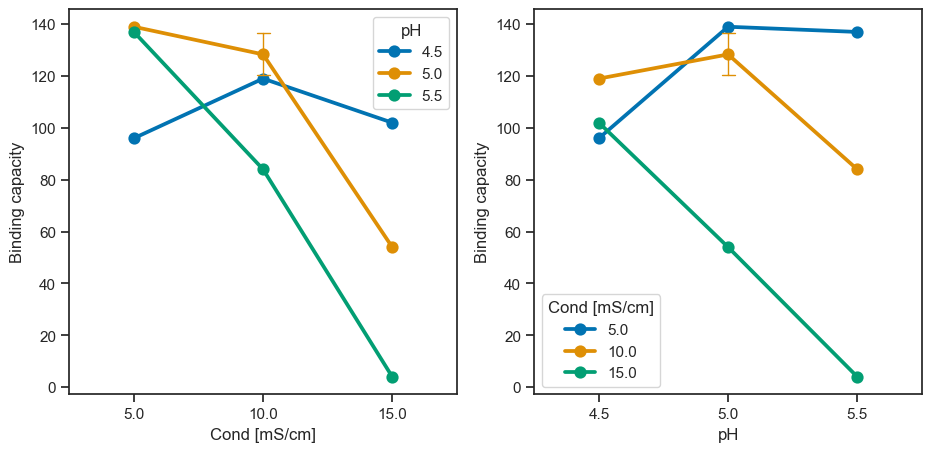

In [32]:
final_model.data_plot()

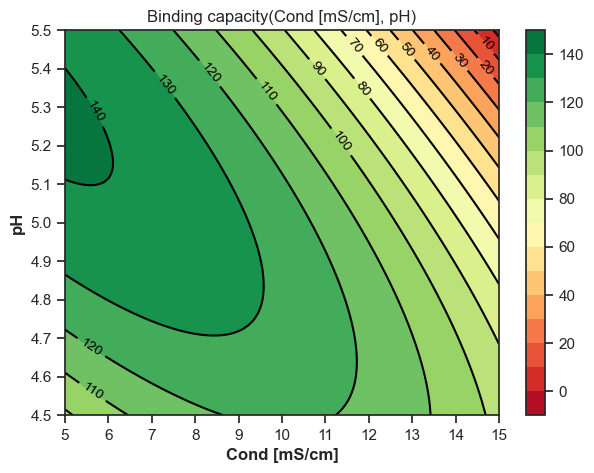

In [33]:
final_model.rsp(figure_size = (7,5), step_x = 1, step_y = 0.1, dpi = 100,
          contours_number = 15, contour_color = "black", contour_font_size = 10,  color_map = "RdYlGn")

In [ ]:
final_model.solve()

Cond [mS/cm]: 3.30
pH: 5.41
Critical value: 142.51
Hessian matrix eigenvalues: [-0.63, -152.44]
